# PROJECT: MUSICAL EVOLUTION ANALYSIS (1950s - 2020s)

DESCRIPTION:
This project conducts a data-driven analysis of the evolution of popular music 
over the last eight decades. By curating a dataset of approximately 100- 150 
representative songs per decade (ranging from the 1950s to the 2020s), we aim 
to identify trends in lyrical content, song structure, and sentiment. All the songs we obtained from the All Out official playlists by Spotify. 

METHODOLOGY:
We leverage the 'spotipy' library to extract metadata (year, song, artist, popularity, duration, 
explicit content) and the 'lyricsgenius' library to scrape song lyrics. 
Using 'TextBlob' and 'NLTK' for Natural Language Processing (NLP), we calculate 
advanced metrics to understand the "soul" of the music across generations.

KEY METRICS CALCULATED:
1. Polarity: Measures the sentiment of the lyrics on a scale from 
   -1.0 (Very Negative/Sad) to 1.0 (Very Positive/Happy).
2. Subjectivity: Measures how subjective the lyrics are on a scale from 
   0.0 (Objective/Factual) to 1.0 (Personal/Emotional).
3. Lexical Richness (%): The percentage of unique words used, indicating 
   vocabulary complexity.
4. Lyrical Density (Words/Min): The number of words sung per minute, often 
   used as a proxy for the song's energy or genre style (e.g., Rap vs. Ballads).


## Initial Setup

In [1]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import lyricsgenius as lg
import pandas as pd
import requests
import os
import re
import time
from textblob import TextBlob
import nltk
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text 
import numpy as np
from tqdm import tqdm
from IPython.display import display

###  1. Keys / Credentials


In [ ]:
CLIENT_ID = '[YOUR_CLIENT_ID]'
CLIENT_SECRET = '[YOUR_CLIENT_SECRET]'
GENIUS_TOKEN = '[YOUR_GENIUS_TOKEN]'

### 2. Network Configuration


In [3]:
session = requests.Session()
session.trust_env = False 
os.environ.pop('HTTP_PROXY', None)
os.environ.pop('HTTPS_PROXY', None)

### 3. Connection

In [4]:
auth = SpotifyClientCredentials(client_id=CLIENT_ID, client_secret=CLIENT_SECRET)
sp = spotipy.Spotify(auth_manager=auth, requests_session=session)
genius = lg.Genius(GENIUS_TOKEN, verbose=False, timeout=15)

### 4. Playlists

In [5]:
playlists_decades = {
    '1950s': '0hrPYkom4Vc1U3ep5lTpki',
    '1960s': '6X4MXiEwRohLqNUE67f9m4',
    '1970s': '5WJDB8X3AiksWiOMPVDFDf',
    '1980s': '2ikyATwHL2gdCMNlIblSmb',
    '1990s': '6w115bkFS6AsSWTkXTxUWL',
    '2000s': '6WMRgS5nbzjM6xvhZppKDl',
    '2010s': '04WQqIiZB8qXsirRwDFPbX',
    '2020s': '3L3yHSJle9RT8QHbpiSZpI'
}

### 5. Function definitions

In [ ]:
def clean_lyrics(letra_raw):
    # Cleans headers like [Chorus] and empty lines
    return "\n".join([line for line in letra_raw.splitlines() 
                      if not line.startswith('[') and line.strip()])

In [22]:
def generate_dataset(playlists, limit=None):
    master_list = []
    print(f"Starting extraction...")
    
    # Cache to avoid querying the same artist's genre twice
    genre_cache = {}

    for decade, playlist_id in playlists.items():
        print(f"\nProcessing Decade: {decade}...")
        
        try:
            if limit:
                results = sp.playlist_tracks(playlist_id, limit=limit)
                tracks = results['items']
            else:
                results = sp.playlist_tracks(playlist_id)
                tracks = results['items']
                while results['next']:
                    results = sp.next(results)
                    tracks.extend(results['items'])
        except Exception as e:
            print(f"Error downloading playlist {decade}: {e}")
            continue

        print(f"Analyzing {len(tracks)} songs...")

        for i, item in enumerate(tracks):
            track = item['track']
            if not track: continue
            
            name = track['name']
            artist = track['artists'][0]['name']
            artist_id = track['artists'][0]['id']
            
            # Default values
            genres = []
            final_lyrics = None
            genius_visits = 0
            num_writers = 0
            polarity = 0.0
            subjectivity = 0.0
            total_words = 0
            lexical_richness = 0.0
            words_per_minute = 0.0
            
            # 1. SPOTIFY DATA
            if artist_id in genre_cache:
                genres = genre_cache[artist_id]
            else:
                try:
                    artist_info = sp.artist(artist_id)
                    genres = artist_info['genres']
                    genre_cache[artist_id] = genres
                except:
                    pass

            # 2. GENIUS DATA & NLP
            try:
                song = genius.search_song(title=name, artist=artist)
                
                if song:
                    try:
                        genius_visits = getattr(song.stats, 'pageviews', 0)
                    except:
                        genius_visits = 0
                    
                    try:
                        if hasattr(song, 'writer_artists'):
                            num_writers = len(song.writer_artists)
                    except:
                        num_writers = 0

                    if song.lyrics:
                        final_lyrics = clean_lyrics(song.lyrics)
                        
                        # --- NLP ANALYSIS ---
                        blob = TextBlob(final_lyrics)
                        polarity = round(blob.sentiment.polarity, 3)
                        subjectivity = round(blob.sentiment.subjectivity, 3)
                        
                        words = blob.words
                        total_words = len(words)
                        if total_words > 0:
                            unique = len(set([w.lower() for w in words]))
                            lexical_richness = round((unique / total_words) * 100, 2)
                            
                            dur_min = track['duration_ms'] / 60000
                            if dur_min > 0:
                                words_per_minute = round(total_words / dur_min, 2)

            except Exception as e:
                pass 

            # 3. APPEND TO LIST
            master_list.append({
                'Decade': decade,
                'Year': track['album']['release_date'][:4],
                'Song': name,
                'Artist': artist,
                'Genres': ", ".join(genres),
                'Popularity': track['popularity'],
                'Duration (min)': round(track['duration_ms'] / 60000, 2),
                'Explicit': track['explicit'],

                # Computed Metrics
                'Polarity': polarity,
                'Subjectivity': subjectivity,
                'Total Words': total_words,
                'Lexical Richness (%)': lexical_richness,
                'Words per Minute': words_per_minute,
                'Lyrics': final_lyrics
            })
            
            if (i+1) % 5 == 0:
                print(f"{i+1} processed...")

    return pd.DataFrame(master_list)

### 6. Execution

In [24]:
df_final = generate_dataset(playlists_decades, limit=100) 

if not df_final.empty:
    print("\n" + "="*50)
    print(f"💾 DATASET CREATED: {len(df_final)} rows.")
    print("="*50)
    
    cols_check = ['Song', 'Artist', 'Polarity', 'Total Words']
    print(df_final[cols_check])

df_final.to_csv('dataset_music.csv', index=False, encoding='utf-8-sig')

Starting extraction...

Processing Decade: 1950s...
Analyzing 100 songs...
5 processed...
10 processed...
15 processed...
20 processed...
25 processed...
30 processed...
35 processed...
40 processed...
45 processed...
50 processed...
55 processed...
60 processed...
65 processed...
70 processed...
75 processed...
80 processed...
85 processed...
90 processed...
95 processed...
100 processed...

Processing Decade: 1960s...
Analyzing 100 songs...
5 processed...
10 processed...
15 processed...
20 processed...
25 processed...
30 processed...
35 processed...
40 processed...
45 processed...
50 processed...
55 processed...
60 processed...
65 processed...
70 processed...
75 processed...
80 processed...
85 processed...
90 processed...
95 processed...
100 processed...

Processing Decade: 1970s...
Analyzing 100 songs...
5 processed...
10 processed...
15 processed...
20 processed...
25 processed...
30 processed...
35 processed...
40 processed...
45 processed...
50 processed...
55 processed...
60 pro

### 7. Load the local copy

In [6]:
df_final = pd.read_csv('dataset_music.csv')

## Part 1: ETL

We first check for any missing values in the dataframe: NaNs and 0s

In [10]:
# 1. Count NaNs (null values) per column
nan_counts = df_final.isna().sum()

# 2. Count Zeros per column
# For boolean columns (like 'Explicit'), 0 represents False.
# For numeric columns, it represents the actual number 0.
zero_counts = (df_final == 0).sum()

# Create a summary dataframe
summary = pd.DataFrame({'NaN Count': nan_counts, 'Zero Count': zero_counts})

# Filter to show only columns that have at least one NaN or Zero
relevant_cols = summary[(summary['NaN Count'] > 0) | (summary['Zero Count'] > 0)]

print("Summary of NaNs and Zeros per column:")
print(relevant_cols)

# 3. Breakdown by Decade
# We iterate through the relevant columns to see the distribution of these values across decades.
details = {}
for col in relevant_cols.index:
    # Analyze NaNs distribution by Decade
    if relevant_cols.loc[col, 'NaN Count'] > 0:
        nan_by_decade = df_final[df_final[col].isna()]['Decade'].value_counts()
        details[f"{col} - NaNs"] = nan_by_decade
    
    # Analyze Zeros distribution by Decade
    if relevant_cols.loc[col, 'Zero Count'] > 0:
        zero_by_decade = df_final[df_final[col] == 0]['Decade'].value_counts()
        details[f"{col} - Zeros"] = zero_by_decade

print("\nBreakdown by Decade:")
for key, value in details.items():
    print(f"\n{key}:")
    print(value)

Summary of NaNs and Zeros per column:
                      NaN Count  Zero Count
Genres                      313           0
Explicit                      0         706
Polarity                      0         136
Subjectivity                  0         133
Total Words                   0         116
Lexical Richness (%)          0         116
Words per Minute              0         116
Lyrics                      116           0

Breakdown by Decade:

Genres - NaNs:
Decade
2020s    64
2000s    57
2010s    57
1980s    45
1990s    39
1970s    30
1960s    20
1950s     1
Name: count, dtype: int64

Explicit - Zeros:
Decade
1950s    100
1960s    100
1970s    100
1980s     98
1990s     96
2010s     77
2000s     76
2020s     59
Name: count, dtype: int64

Polarity - Zeros:
Decade
1980s    27
1950s    22
1970s    22
1960s    20
1990s    19
2020s    13
2000s     7
2010s     6
Name: count, dtype: int64

Subjectivity - Zeros:
Decade
1980s    27
1950s    22
1970s    22
1960s    20
1990s    18
2020s

#### Why Are There Zeros or Nulls?

Here is an explanation of the possible reasons for the values we found in each case:

1. Genres (313 NaNs)

* **Cause:** Missing metadata in the original source.
* **Explanation:** Music databases sometimes lack genre tags for all songs. Interestingly, we saw that the **2020s** have many nulls (64), which may be because these are very new songs that haven't been properly classified yet or belong to micro-genres that the database didn't recognize.


2. Lyrics, Total Words, Lexical Richness, Words per Minute (WPM)

* **Cause:** Instrumental songs or an error in lyric retrieval.
* **Explanation:** These columns are correlated. If **Lyrics** is **NaN** (null), the words cannot be counted, so **Total Words**, **Lexical Richness**, and **WPM** are automatically filled with **0**.
    * It is possible that some are **instrumentals** (no lyrics).
    * However, given the high number of cases in the **50s-80s**, it is likely that the lyrics were simply **not found** by the service used to create the dataset (e.g., Genius or Musixmatch) due to title discrepancies or copyright issues.


3. Explicit (706 Zeros)

* **Cause:** Cultural evolution and censorship (Not an error).
* **Explanation:** In this column, **0** means **False** (the song is not explicit).
    * We observed that in the **50s, 60s, and 70s**, 100% of the values are **0**. This reflects the strict radio censorship and social norms of the time.
    * As the decades progress (especially since the 90s with Hip Hop), the number of "zeros" decreases because more songs are marked as **True** (explicit).


4. Polarity and Subjectivity

* **Cause:** Lack of text to analyze.
* **Explanation:** "Polarity" measures whether a song is happy/positive or sad/negative. If there are no lyrics (because it is **NaN**), the sentiment analysis algorithm returns a default neutral value: **0.0**.
    * There are 116 songs without lyrics and 136 with a polarity of **0**.
    * The difference (about 20 songs) are likely songs that *do* have lyrics, but whose content is so ambiguous or repetitive that the algorithm deemed it "perfectly neutral."

-------
So the important missings are:
- Genre
- Lyrics

Lets check the exact songs:

In [19]:
cond_genre = df_final['Genres'].isna()
cond_lyrics = (df_final['Lyrics'].isna()) | (df_final['Total Words'] == 0)

df_final['Problem_Type'] = None
df_final['Problem_Type'] = df_final['Problem_Type'].astype('object')

df_final.loc[cond_genre & cond_lyrics, 'Problem_Type'] = 'Both Missing'
df_final.loc[cond_genre & ~cond_lyrics, 'Problem_Type'] = 'Missing Genre Only'
df_final.loc[~cond_genre & cond_lyrics, 'Problem_Type'] = 'Missing Lyrics Only'

summary = df_final[df_final['Problem_Type'].notna()].groupby(['Decade', 'Problem_Type']).size().unstack(fill_value=0)
summary['Total Issues'] = summary.sum(axis=1)
total_row = summary.sum().to_frame().T
total_row.index = ['Total']
final_summary = pd.concat([summary, total_row])

print("--- Summary of Issues by Decade ---")
table_str = final_summary.astype(int).to_markdown()
lines = table_str.split('\n')
lines.insert(-1, lines[1]) 
print('\n'.join(lines))

print("\n--- Detailed List (Sample) ---")
cols = ['Decade', 'Problem_Type', 'Song', 'Artist']
print(df_final[df_final['Problem_Type'].notna()][cols].head().to_markdown(index=False))

df_problems = df_final[df_final['Problem_Type'].notna()].copy()

--- Summary of Issues by Decade ---
|       |   Both Missing |   Missing Genre Only |   Missing Lyrics Only |   Total Issues |
|:------|---------------:|---------------------:|----------------------:|---------------:|
| 1950s |              1 |                    0 |                    20 |             21 |
| 1960s |              2 |                   18 |                    17 |             37 |
| 1970s |              5 |                   25 |                    16 |             46 |
| 1980s |             10 |                   35 |                    16 |             61 |
| 1990s |              5 |                   34 |                    11 |             50 |
| 2000s |              1 |                   56 |                     1 |             58 |
| 2010s |              3 |                   54 |                     2 |             59 |
| 2020s |              4 |                   60 |                     2 |             66 |
|:------|---------------:|---------------------:|-----

Let's first tackle the lyrics issue. As we go through the problems list, we can se see that the main issues is that the song name imported from spotify is not the same as the one genius uses, so it does not find the lyrics. To solve this, we need to transform the song name to match the one used by genius.

In [20]:
df_cleaned = df_problems.copy()

def clean_song_title(title):
    if not isinstance(title, str): return str(title)
    
    # Remove everything after " - " (remasters, versions)
    if " - " in title: title = title.split(" - ")[0]
    
    # Remove content inside parentheses and brackets
    title = re.sub(r"\(.*?\)|\[.*?\]", "", title)
    
    # Remove "feat." or "ft." 
    title = re.sub(r"(?i)\b(feat\.?|ft\.?)\b.*", "", title)
    
    # Remove quotes
    title = title.replace('"', '').replace("'", "")
    
    # Normalize common abbreviations (The "Mister" -> "Mr." fix)
    replacements = {r"\bMister\b": "Mr.", r"\bDoctor\b": "Dr.", r"\bSaint\b": "St."}
    for pat, rep in replacements.items():
        title = re.sub(pat, rep, title, flags=re.IGNORECASE)

    return " ".join(title.split())

df_cleaned['Cleaned_Song'] = df_cleaned['Song'].apply(clean_song_title)


Now, we make the call to the Genius API to fetch the lyrics for the corrected problematic songs, creating again the computed columns in order to have the problematic dataframe with the same structure as the original one.

In [25]:

# --- CONFIGURATION ---
GENIUS_TOKEN = 'tJhn9mkLiS5uadMdwpQpjnXvjgn2tw7pQGuwhhXays6nu7mWx38I41PysLdvQkA8'
genius = lg.Genius(GENIUS_TOKEN, verbose=False, remove_section_headers=True, timeout=15)

# --- PROCESSING ---
print(f"Starting enrichment for {len(df_problems)} songs...")

df_work = df_cleaned.copy()

tqdm.pandas(desc="Fetching Lyrics")

def fetch_and_calculate(row):
    # Skip if the problem is only a missing genre (we focus on lyrics here)
    if row['Problem_Type'] == 'Missing Genre Only':
        return row 

    lyrics = None
    target = row['Cleaned_Song']
    artist = row['Artist']
    
    # 1. SEARCH LYRICS
    try:
        # Strategy A: Cleaned Title
        song = genius.search_song(target, artist)
        
        # Strategy B: Broad Search (Smart Match) if A fails
        if not song:
            hits = genius.search_songs(target)
            if hits and 'hits' in hits:
                for hit in hits['hits'][:3]:
                    h_artist = hit['result']['primary_artist']['name']
                    # Check if artist matches (one is inside the other)
                    if artist.lower() in h_artist.lower() or h_artist.lower() in artist.lower():
                        song = genius.search_song(hit['result']['title'], h_artist)
                        break
        
        if song and song.lyrics:
            lyrics = song.lyrics
    except:
        pass # Ignore connection errors

    # 2. CALCULATE METRICS (If lyrics found)
    if lyrics:
        row['Lyrics'] = lyrics
        
        # NLP Pre-processing
        clean_txt = "\n".join([line for line in lyrics.splitlines() if not line.startswith('[')])
        blob = TextBlob(clean_txt)
        
        # Sentiment
        row['Polarity'] = round(blob.sentiment.polarity, 3)
        row['Subjectivity'] = round(blob.sentiment.subjectivity, 3)
        
        # Word Counts
        words = blob.words
        total_words = len(words)
        row['Total Words'] = total_words
        
        if total_words > 0:
            unique = len(set([w.lower() for w in words]))
            row['Lexical Richness (%)'] = round((unique / total_words) * 100, 2)
            
            # WPM Calculation
            if row['Duration (min)'] > 0:
                row['Words per Minute'] = round(total_words / row['Duration (min)'], 2)
        else:
            row['Lexical Richness (%)'] = 0.0
            row['Words per Minute'] = 0.0

    return row

# Apply the function
df_repaired = df_work.progress_apply(fetch_and_calculate, axis=1)

# Filter: Keep only the successfully repaired songs
df_fixed_final = df_repaired[df_repaired['Lyrics'].notna() & (df_repaired['Total Words'] > 0)].copy()

# Cleanup: Remove the temporary helper column
if 'Cleaned_Song' in df_fixed_final.columns:
    df_fixed_final = df_fixed_final.drop(columns=['Cleaned_Song'])

# Save the Fixed Data (Crucial for the Merge step)
df_fixed_final.to_csv('dataset_fixed.csv', index=False)
print(f"Success! Saved {len(df_fixed_final)} repaired songs to 'dataset_fixed.csv'")

Starting enrichment for 398 songs...


Fetching Lyrics: 100%|██████████| 398/398 [06:10<00:00,  1.08it/s]

Success! Saved 393 repaired songs to 'dataset_fixed.csv'


We have recover 393 from the 398 problematics lyrics. That is awesome! Let's now merge the fixed dataset with the original one. However, lets check if we have any duplicates in the original dataframe cause otherwise the merge will fail.

In [32]:
# Check for duplicates based on Artist and Song
duplicates = df_final[df_final.duplicated(subset=['Artist', 'Song'], keep=False)]

print(f"Found {len(duplicates)} duplicate rows.")
print(duplicates[['Artist', 'Song', 'Decade']].sort_values(by='Song').head(10))

Found 10 duplicate rows.
              Artist                            Song Decade
544        Lady Gaga                     Bad Romance  2000s
662        Lady Gaga                     Bad Romance  2010s
206         The Cure                  Boys Don't Cry  1970s
317         The Cure                  Boys Don't Cry  1980s
318     Depeche Mode               Enjoy the Silence  1980s
417     Depeche Mode               Enjoy the Silence  1990s
214  Michael Jackson  Rock with You - Single Version  1970s
332  Michael Jackson  Rock with You - Single Version  1980s
248      The Buggles     Video Killed The Radio Star  1970s
362      The Buggles     Video Killed The Radio Star  1980s


There are 5 duplicated songs, we will keep the first appearance and drop the rest. Both in the original dataset and in the fixed one.

In [35]:
df_merged = df_final.copy()

# Clean the destination
df_merged = df_merged.drop_duplicates(subset=['Artist', 'Song'], keep='first')

# Clean the source
df_fixed_final = df_fixed_final.drop_duplicates(subset=['Artist', 'Song'], keep='first')

print(f"Unique rows in Main DB: {len(df_merged)}")
print(f"Unique rows in Updates: {len(df_fixed_final)}")

# Set indices for the merge
df_merged = df_merged.set_index(['Artist', 'Song'])
df_updates = df_fixed_final.set_index(['Artist', 'Song'])

df_merged.update(df_updates)

# Reset index to return to normal
df_merged = df_merged.reset_index()

# Cleanup error labels
fixed_indices = df_updates.index
mask_fixed = df_merged.set_index(['Artist', 'Song']).index.isin(fixed_indices)
df_merged.loc[mask_fixed, 'Problem_Type'] = None

# Verification
def count_issues(df):
    # Count rows where Lyrics are missing (NaN) OR Total Words is 0
    return len(df[(df['Lyrics'].isna()) | (df['Total Words'] == 0)])

print("\n--- Final Result ---")
print(f"Issues before merge: {count_issues(df_final)}")
print(f"Issues after merge:  {count_issues(df_merged)}")

Unique rows in Main DB: 795
Unique rows in Updates: 391

--- Final Result ---
Issues before merge: 116
Issues after merge:  5


Now we finally check our lyrics missings again, and the magic should have happened

In [36]:
print("--- Data Health Check (df_merged) ---")

# 1. Check for NaNs
print(f"Missing Genres (NaN):   {df_merged['Genres'].isna().sum()}")
print(f"Missing Lyrics (NaN):   {df_merged['Lyrics'].isna().sum()}")

# 2. Check for Zeros (Empty processing)
print(f"Zero Total Words:       {(df_merged['Total Words'] == 0).sum()}")

# 3. Combined Lyric Issues (NaN OR Zero)
lyric_issues = len(df_merged[(df_merged['Lyrics'].isna()) | (df_merged['Total Words'] == 0)])
print(f"-----------------------")
print(f"TOTAL Lyric Issues:     {lyric_issues}")

--- Data Health Check (df_merged) ---
Missing Genres (NaN):   311
Missing Lyrics (NaN):   5
Zero Total Words:       5
-----------------------
TOTAL Lyric Issues:     5


Now the only problem left is the NaNs in Genre, Spotify did not provided them so we call the Genius API again.

In [37]:
# 1. Identify rows that need Genre repair
# We filter where Genres is NaN
missing_genre_mask = df_merged['Genres'].isna()
df_missing_genres = df_merged[missing_genre_mask].copy()

print(f"Attempting to find genres for {len(df_missing_genres)} songs using Genius Tags...")

# 2. Function to fetch Tags
def fetch_genius_tags(row):
    try:
        # Search for the song
        song = genius.search_song(row['Song'], row['Artist'])
        
        if song:
            # genius_song.to_dict() returns a dictionary with metadata including tags
            # We assume the library returns a 'tags' key in the dictionary representation
            data = song.to_dict()
            
            # Extract tags (usually a list of dicts like [{'name': 'Pop'}, ...])
            # Depending on the library version, it might be directly in 'tags'
            tags = []
            if 'tags' in data:
                tags = [t['name'] for t in data['tags']]
            
            # If no tags in the top level, sometimes they are in primary_tag
            if not tags and 'primary_tag' in data and data['primary_tag']:
                tags.append(data['primary_tag']['name'])

            # Join them into a string (e.g., "Pop, Rock, Soul")
            if tags:
                return ", ".join(tags[:3]) # Take top 3 tags
                
    except Exception as e:
        return None
    
    return None

# 3. Apply the function
tqdm.pandas(desc="Fetching Genres")
df_missing_genres['Found_Tags'] = df_missing_genres.progress_apply(fetch_genius_tags, axis=1)

# 4. Update the Main DataFrame
# We only want to update where we actually found something
filled_genres = df_missing_genres[df_missing_genres['Found_Tags'].notna()]

# Update the 'Genres' column in the main df using the indices
df_merged.loc[filled_genres.index, 'Genres'] = filled_genres['Found_Tags']

# 5. Final Check
remaining = df_merged['Genres'].isna().sum()
print(f"-------------------------------")
print(f"Genres recovered: {len(filled_genres)}")
print(f"Still missing:    {remaining}")

Attempting to find genres for 311 songs using Genius Tags...


Fetching Genres: 100%|██████████| 311/311 [15:29<00:00,  2.99s/it]

-------------------------------
Genres recovered: 0
Still missing:    311


It could not recover any genre, so the problem has to be the dificulty to classify these songs, as all of them are relatively recent. Normaly, the artist are the ones how have genre labels, and the songs get them from the artist, however, this process is not perfect. We will leave the genre column with missing values but change the NaNs to "Unknown". We will also get rid of the last 5 rows without lyrics

In [ ]:
# 1. Fill missing Genres with 'Unknown'
# This prevents NaNs from breaking future plots/analysis
df_merged['Genres'] = df_merged['Genres'].fillna('Unknown')

# 2. Remove songs that have missing Lyrics (NaN) OR very few words (< 4)
# This removes instrumentals (like 'Children'), outliers (like 'Tequila'), 
# or songs where lyrics weren't found.
rows_before = len(df_merged)

# Drop NaNs first
df_merged = df_merged.dropna(subset=['Lyrics'])

# Drop songs with less than 4 words (e.g., "Tequila", intros, etc.)
# We assume 'Total Words' exists. If not, calculate it or skip this line.
df_merged = df_merged[df_merged['Total Words'] >= 4]

dropped = rows_before - len(df_merged)

if dropped > 0:
    print(f"Removed {dropped} songs (Instrumentals, 'Tequila' cases, or missing lyrics).")

# 3. Final Summary
print("\n--- Final Dataset Statistics ---")
print(f"Total rows:      {len(df_merged)}")
print(f"Null in Genre:   {df_merged['Genres'].isna().sum()}")
print(f"Null in Lyrics:  {df_merged['Lyrics'].isna().sum()}")
print(f"Min Words:       {df_merged['Total Words'].min()}")

# 4. Save final CSV
# We use 'utf-8-sig' so Excel opens special characters correctly
filename = 'dataset_final_completed.csv'
df_merged.to_csv(filename, index=False, encoding='utf-8-sig')


Removed 1 songs (Instrumentals, 'Tequila' cases, or missing lyrics).

--- Final Dataset Statistics ---
Total rows:      789
Null in Genre:   0
Null in Lyrics:  0
Min Words:       64

Success! Clean dataset saved as 'dataset_final_completed.csv'


In [7]:
df = pd.read_csv('dataset_final_completed.csv')

## Part 2: Lexical Richness

There is a longstanding belief among music critics and older generations that "music from the past was more cultured," while today's hits are merely "repetitive trash." We set out to test this claim mathematically by analyzing Lexical Richness—the percentage of unique words used in a song relative to its total word count.

### The Great Decline (1950s - 2010s)

Initially, our data seems to confirm the critics' worst fears. As seen in the macro-analysis below, there is a clear, multi-decade trend toward lexical impoverishment.

The Golden Age: In the 1950s, the average hit song was lexically diverse, with 36% of its words being unique.

The Simplification: From there, richness dropped consistently every single decade, hitting a historic low of 28% in the 2000s and 2010s. This era, defined by stadium anthems and earworm pop, prioritized repetitive hooks and simple choruses designed for radio dominance.

### The 2020s Plot Twist: The "Streaming Density" Effect

However, the data reveals a surprising uptrend in the current decade. The 2020s show a sharp resurgence in complexity, jumping back up to 33% unique words—levels not seen since the 1970s. Does this mean songwriters suddenly became more poetic? Not necessarily.

This could be due to structural changes in the streaming era. Songs are becoming shorter, often cutting out long instrumental breaks or repetitive bridges. With less time to repeat the same hook over and over, the ratio of unique lyrics naturally increases, 'densifying' the vocabulary of modern hits.

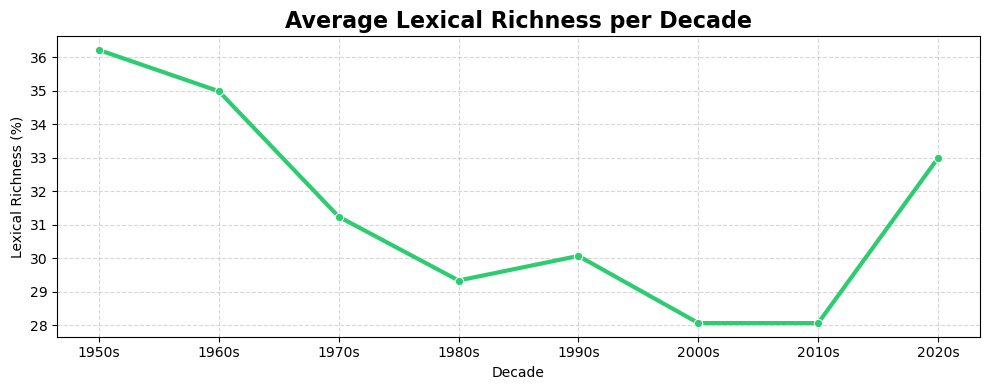

In [51]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='Decade', y='Lexical Richness (%)', marker='o', color='#2ecc71', linewidth=3, errorbar=None)
plt.title('Average Lexical Richness per Decade', fontsize=16, weight='bold')
plt.ylabel('Lexical Richness (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

To confirm our hypothesis about the 'density' of modern songs, let's look at the evolution of song duration. If songs are indeed getting shorter while vocabulary stays consistent or grows, the lexical density naturally increases.

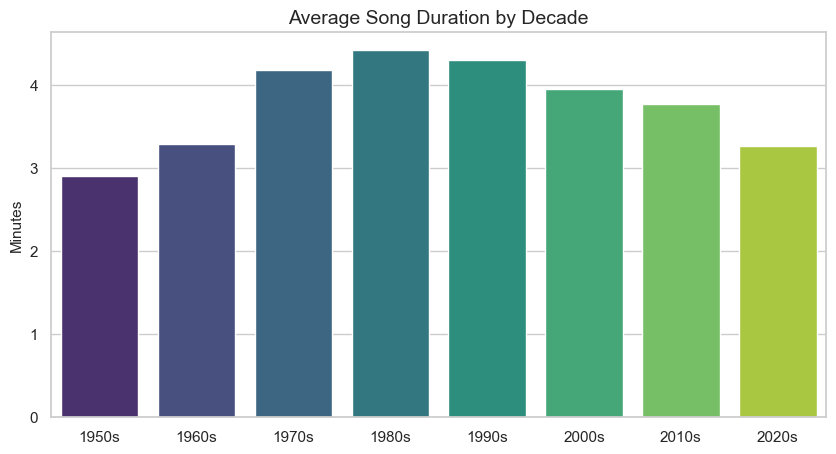

In [54]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Decade', y='Duration (min)', hue='Decade', errorbar=None, palette='viridis', legend=False)
plt.title('Average Song Duration by Decade', fontsize=14)
plt.ylabel('Minutes', fontsize=11)
plt.xlabel('')
plt.show()

As shown in the chart, the average song length experienced a dramatic structural shift. Duration grew consistently from the 1950s (around 2.9 minutes) until it peaked in the 1980s (over 4.2 minutes), coinciding with the peak era of the Album and CD formats.

Crucially, since the 1990s, duration has declined, a trend that accelerated sharply in the 2020s, dropping to roughly 3.2 minutes. This structural shortening directly validates our hypothesis regarding the recent increase in lexical richness: songs are being condensed to maximize streaming payouts and listener engagement. Artists are forced to cut instrumental sections and lengthy, repetitive bridges, thereby densifying the lyrical content in the time remaining.

---
Returning to lyrics, we won't just look at averages. We are going to find the culprits. We will identify the exact songs that dragged the statistics down and those that are lifting it up:

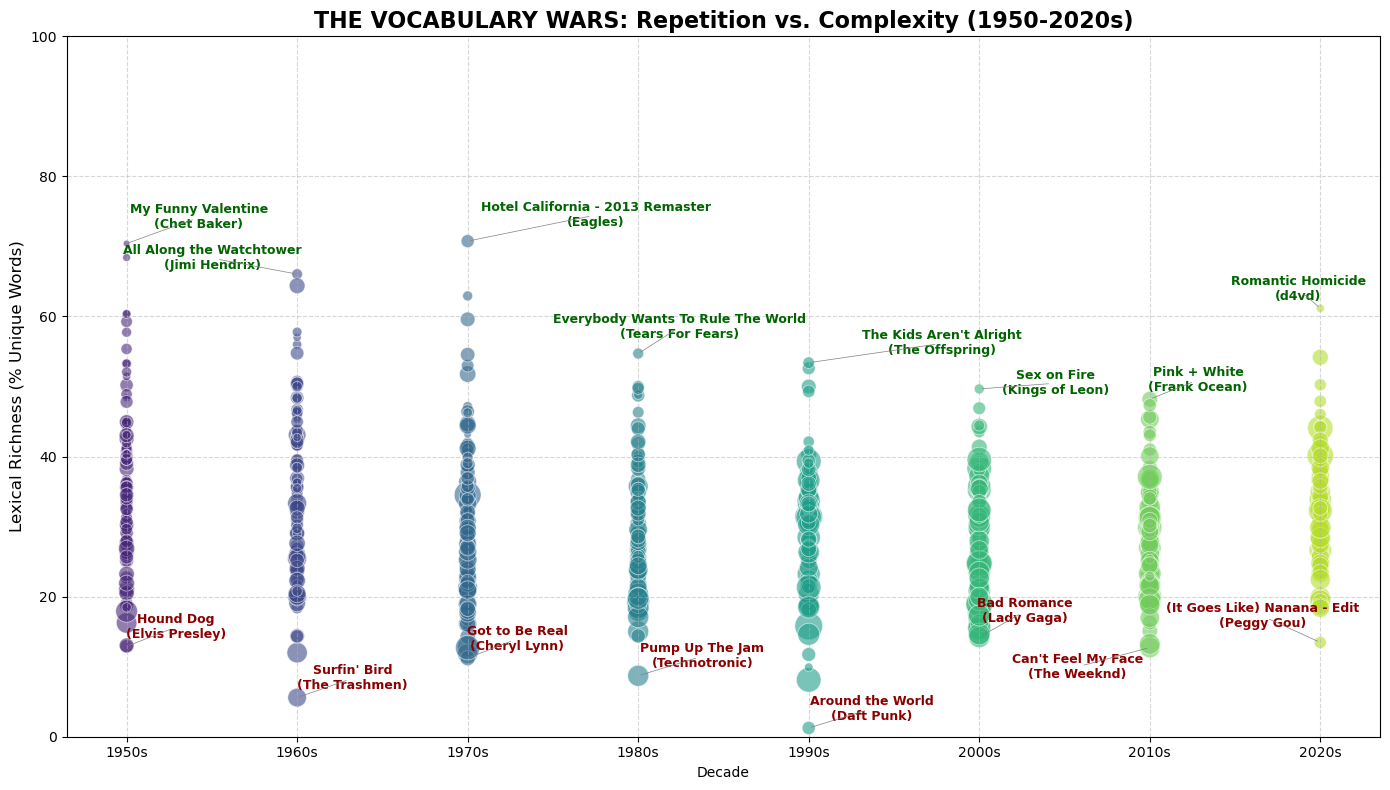

In [62]:
sns.set_theme(style="whitegrid")
plt.style.use('default')

def analyze_lexical_depth(df):

    # Filter valid lyrics: Ignore instrumental/intro tracks (less than 20 words) to avoid noise
    valid_data = df[(df['Total Words'] > 20)].copy()
    
    # Sort decades for correct plotting order
    valid_data = valid_data.sort_values('Decade')

    plt.figure(figsize=(14, 8))
    
    scatter = sns.scatterplot(
        data=valid_data, 
        x='Decade', 
        y='Lexical Richness (%)',
        size='Total Words',
        hue='Decade',
        sizes=(20, 400),
        alpha=0.6,
        palette='viridis',
        legend=False
    )

    texts = []
    
    for decade in valid_data['Decade'].unique():
        decade_data = valid_data[valid_data['Decade'] == decade]
        
        # Find extremes
        most_complex = decade_data.nlargest(1, 'Lexical Richness (%)')
        most_repetitive = decade_data.nsmallest(1, 'Lexical Richness (%)')
        
        # Label Highest (Green)
        for _, row in most_complex.iterrows():
            texts.append(plt.text(
                x=row['Decade'], 
                y=row['Lexical Richness (%)'], 
                s=f"{row['Song']}\n({row['Artist']})", 
                fontsize=9, 
                ha='center', 
                fontweight='bold',
                color='darkgreen'
            ))
            
        # Label Lowest (Red)
        for _, row in most_repetitive.iterrows():
            texts.append(plt.text(
                x=row['Decade'], 
                y=row['Lexical Richness (%)'], 
                s=f"{row['Song']}\n({row['Artist']})", 
                fontsize=9, 
                ha='center', 
                fontweight='bold',
                color='darkred'
            ))

    plt.title('THE VOCABULARY WARS: Repetition vs. Complexity (1950-2020s)', fontsize=16, weight='bold')
    plt.ylabel('Lexical Richness (% Unique Words)', fontsize=12)
    plt.xlabel('Decade')
    plt.ylim(0, 100)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    adjust_text(texts, expand_points=(1.5, 1.5), arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, shrinkA=5))
    
    plt.tight_layout()
    plt.show()

analyze_lexical_depth(df)

Or even better, let's go the hall of fame of richness and repetition.

In [ ]:
pd.set_option('display.max_colwidth', 30)
pd.set_option('display.width', 1000)

print("\n" + "="*60)
print("HALL OF RICHNESS")
print("="*60)
top_overall = df.nlargest(8, 'Lexical Richness (%)')
print(top_overall[['Decade', 'Song', 'Artist', 'Lexical Richness (%)', 'Total Words']].to_string(index=False))

print("\n" + "="*60)
print("HALL OF REPETITION")
print("="*60)
bottom_overall = df.nsmallest(8, 'Lexical Richness (%)')
print(bottom_overall[['Decade', 'Song', 'Artist', 'Lexical Richness (%)', 'Total Words']].to_string(index=False))



HALL OF RICHNESS
Decade                             Song           Artist  Lexical Richness (%)  Total Words
 1970s Hotel California - 2013 Remaster           Eagles                 70.76          236
 1950s               My Funny Valentine       Chet Baker                 70.42           71
 1950s     What A Diff'rence A Day Made Dinah Washington                 68.42           95
 1960s         All Along the Watchtower     Jimi Hendrix                 66.05          162
 1960s                        Bang Bang    Nancy Sinatra                 64.39          337
 1970s               Wish You Were Here       Pink Floyd                 62.94          143
 2020s                Romantic Homicide             d4vd                 61.17          103
 1950s                    Strange Fruit   Billie Holiday                 60.44           91

HALL OF REPETITION
Decade              Song       Artist  Lexical Richness (%)  Total Words
 1990s  Around the World    Daft Punk                  1.25  

## Part 3: Sentiment Analysis

If lexical richness tells us how artists speak, sentiment analysis tells us how they feel. Using a polarity metric ranging from -1 (extremely negative) to +1 (extremely positive), we analyzed the emotional temperature of pop music over the last seven decades.

The results, as shown in the graph below, are undeniable: Mainstream music is getting statistically sadder.

### The Slow Fade of the "Good Vibes"

The 1950s represent the peak of musical optimism in our dataset (~0.20 polarity). This was the era of post-war recovery and "Bubblegum Pop," where lyrics focused heavily on innocent love, dancing, and idealized romance. The vocabulary was simple, but the mood was overwhelmingly bright.

### The "Angst" Drop (1990s)

As we move through the decades, we see a steady decline, but the chart reveals a significant structural break in the 1990s. This decade marked the mainstream explosion of Grunge and Hip-Hop—genres that fundamentally rejected the polished optimism of the past. Artists began to openly discuss struggle, systemic issues, and internal conflict, driving the average sentiment down to ~0.10.

### The 2020s: A New Era of Vulnerability

While the 2000s and 2010s saw a slight "Pop recovery," the 2020s have crashed to the lowest point in history (0.07).

This steep drop is likely not a coincidence. It reflects a cultural shift driven by the global pandemic, social unrest, and a new generation of artists (like Billie Eilish or Olivia Rodrigo) who prioritize radical vulnerability and mental health awareness over escapism. Modern hits don't just "entertain"; they validate anxiety and sadness, resulting in the "darkest" lyrical landscape we have ever seen.

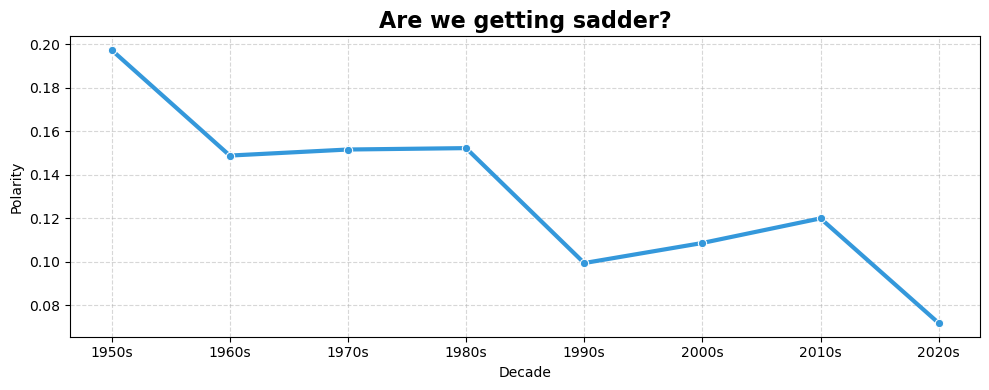

In [67]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='Decade', y='Polarity', marker='o', color='#3498db', linewidth=3, errorbar=None)
plt.title('Are we getting sadder?', fontsize=16, weight='bold')
plt.ylabel('Polarity')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

We established that music is getting sadder. But how are artists expressing this pain?

We hypothesized that modern pop would be hyper-emotional and subjective. However, the data reveals a counter-intuitive trend: Subjectivity is trending downwards/flat.

This suggests a shift from Passion to Detachment.

- The High Subjectivity of the Past: In the 50s, lyrics were often hyper-sentimental declarations of love ("You are wonderful," "I am so happy"). These are opinions, highly subjective.

- The Objective Sadness of the Present: Modern lyrics, heavily influenced by Hip-Hop and alternative pop, often focus on storytelling and realism. Describing a breakup, a night out, or a struggle with detailed nouns and verbs is—technically—more "objective" than using pure emotional adjectives.

The data paints a picture of a generation that is sadder, but also numb-er. The sadness isn't presented as a passionate outcry, but as a cold, hard fact of life.

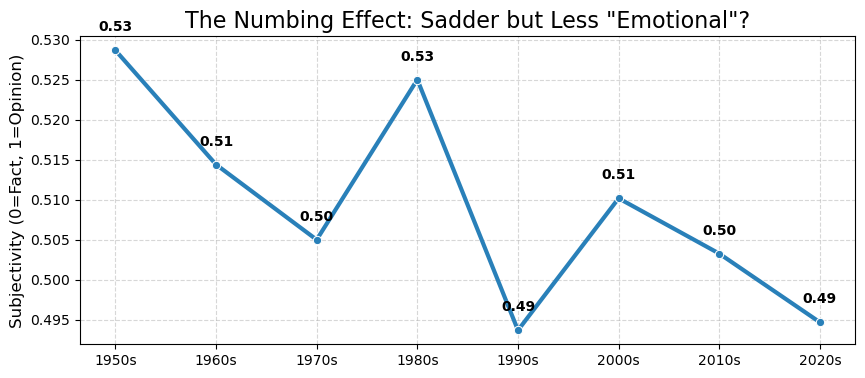

In [74]:
plt.figure(figsize=(10, 4))
subj_trend = df.groupby('Decade')['Subjectivity'].mean().reset_index()
sns.lineplot(data=subj_trend, x='Decade', y='Subjectivity', 
             marker='o', linewidth=3, color='#2980b9') # Blue for "Cold/Detached"

for x, y in zip(subj_trend['Decade'], subj_trend['Subjectivity']):
    plt.text(x, y + 0.002, f'{y:.2f}', ha='center', va='bottom', fontweight='bold')

plt.title('The Numbing Effect: Sadder but Less "Emotional"?', fontsize=16)
plt.ylabel('Subjectivity (0=Fact, 1=Opinion)', fontsize=12)
plt.xlabel('')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

If modern sadness is more "objective" (as seen above), it is also significantly ruder.

To complete our vulnerability study, we look at Explicit Content. This explains the drop in subjectivity: artists are trading "polite metaphors" (which are often subjective poetic devices) for "raw language" (which is often direct and explicit).

The combination of Low Polarity + Low Subjectivity + High Explicit Content defines the modern sound: Brutal Realism.

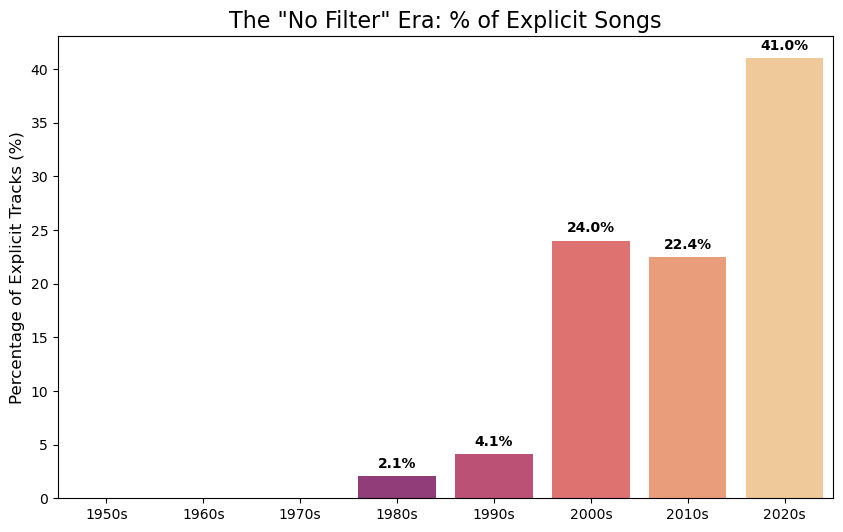

In [76]:
plt.figure(figsize=(10, 6))
explicit_trend = df.groupby('Decade')['Explicit'].mean().reset_index()
explicit_trend['Explicit_Pct'] = explicit_trend['Explicit'] * 100
barplot = sns.barplot(data=explicit_trend, x='Decade', y='Explicit_Pct', hue='Decade', palette='magma', legend=False)

for p in barplot.patches:
    if p.get_height() > 0: 
        barplot.annotate(f'{p.get_height():.1f}%', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', 
                         xytext = (0, 9), 
                         textcoords = 'offset points',
                         fontweight='bold')

plt.title('The "No Filter" Era: % of Explicit Songs', fontsize=16)
plt.ylabel('Percentage of Explicit Tracks (%)', fontsize=12)
plt.xlabel('')
plt.show()

## Part 4: The Great Acceleration
If we look at the speed of delivery, the data suggests that modern music is indeed in a rush. The average "Words Per Minute" (WPM) has skyrocketed by nearly 60% since the 1950s.

### The "Crooner" Era vs. The "Rapper" Era

The graph shows a relatively stable pace from the 1950s to the 1980s. This was the era of melody over density—singers like Elvis or The Beatles let notes breathe.

However, the chart reveals a massive structural break in the 1990s and 2000s, where the average jumped from ~80 to ~115 WPM. This is the "Hip-Hop Inflection Point." As Rap and R&B entered the mainstream, the rhythmic delivery changed. Artists began packing more syllables into every bar, prioritizing rhythmic density over sustained notes.

### The Attention Economy (2020s)

After a slight dip in the 2010s, the 2020s have pushed the speed to a historical maximum. This correlates with the "TikTok Effect" and the shrinking attention span. In an era where a song has 5 seconds to hook a listener before they swipe away, artists are condensing more information into shorter timeframes.

Combined with our previous findings, the profile of the modern hit is clear: It is short, sad, and speaks very, very fast.

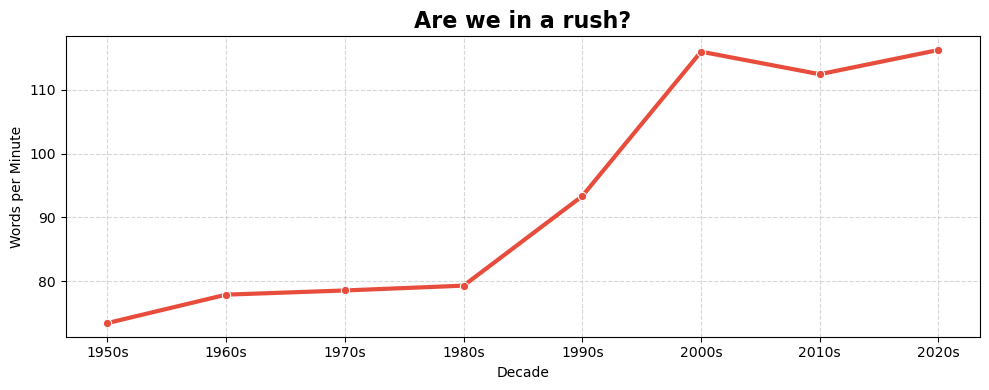

In [66]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='Decade', y='Words per Minute', marker='o', color='#e74c3c', linewidth=3, errorbar=None)
plt.title('Are we in a rush?', fontsize=16, weight='bold')
plt.ylabel('Words per Minute')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

To confirm that the "Great Acceleration" of the 90s is driven by genre shifts, we broke down the "Words Per Minute" by genre.

<div class="alert alert-warning">
  <strong>⚠️ Data Transparency:</strong> We must acknowledge that approximately 40% of our historical dataset lacks specific genre tags (labeled as 'Unknown'). These tracks are excluded from this specific chart to ensure we are comparing clearly defined styles.
</div>

The Result: The boxplot reveals a clear "Speed Hierarchy" that explains the historic trend:

1. The Engine (Hip-Hop): As expected, Hip-Hop is in a league of its own, with a median of ~145 WPM.

2. The Accomplices (Pop & R&B): Crucially, Pop and R&B are the next fastest genres (hovering around 100 WPM). This shows how Hip-Hop's rhythmic influence "bled" into the mainstream, forcing Pop stars to sing faster to compete.

3. The Casualties (Rock & Country): Rock is the slowest genre in the dataset (~65 WPM). The decline of Rock's popularity in the 2000s directly correlates with the rise in average WPM.

In short: The charts got faster because we stopped listening to slow Rock bands and started listening to fast Rappers and rhythmic Pop stars.

Total Songs: 789
Songs with Genre (Analyzed): 369
Songs without Genre (Excluded): 420


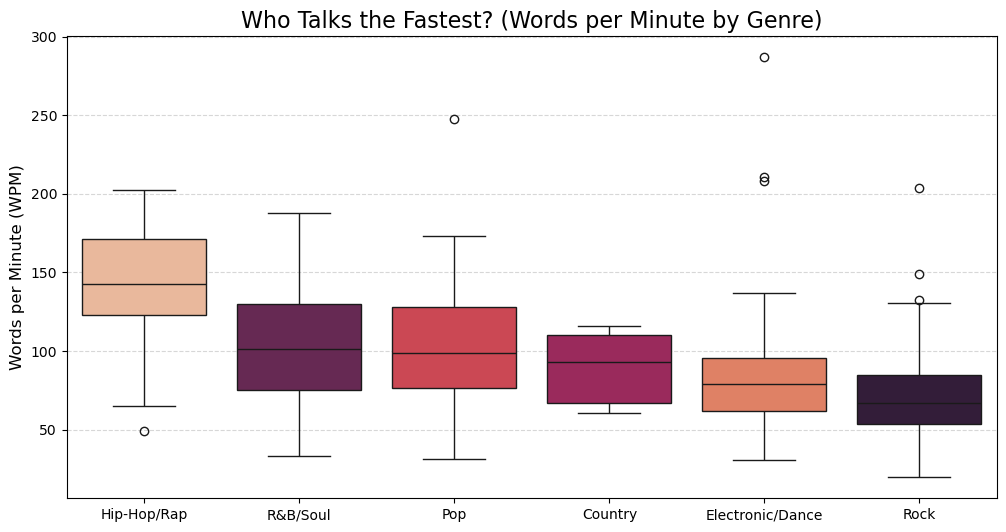

In [81]:
def classify_genre(genre_str):
    genre_str = str(genre_str).lower()
    
    if 'hip hop' in genre_str or 'rap' in genre_str or 'trap' in genre_str:
        return 'Hip-Hop/Rap'
    elif 'rock' in genre_str or 'metal' in genre_str or 'punk' in genre_str:
        return 'Rock'
    elif 'country' in genre_str or 'folk' in genre_str:
        return 'Country'
    elif 'r&b' in genre_str or 'soul' in genre_str or 'motown' in genre_str:
        return 'R&B/Soul'
    elif 'dance' in genre_str or 'electronic' in genre_str or 'house' in genre_str or 'disco' in genre_str:
        return 'Electronic/Dance'
    elif 'pop' in genre_str: 
        return 'Pop'
    else:
        return 'Other/Unknown'

df['Broad_Genre'] = df['Genres'].apply(classify_genre)
plot_genres = df[~df['Broad_Genre'].isin(['Other/Unknown'])]
total_songs = len(df)
analyzed_songs = len(plot_genres)
print(f"Total Songs: {total_songs}")
print(f"Songs with Genre (Analyzed): {analyzed_songs}")
print(f"Songs without Genre (Excluded): {total_songs - analyzed_songs}")
plt.figure(figsize=(12, 6))
order = plot_genres.groupby('Broad_Genre')['Words per Minute'].median().sort_values(ascending=False).index

sns.boxplot(
    data=plot_genres, 
    x='Broad_Genre', 
    y='Words per Minute', 
    hue='Broad_Genre',
    order=order, 
    palette='rocket',
    legend=False
)

plt.title('Who Talks the Fastest? (Words per Minute by Genre)', fontsize=16)
plt.ylabel('Words per Minute (WPM)', fontsize=12)
plt.xlabel('')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()

## Part 5: Correlation Study


1. The Recency Bias (0.59 correlation)

The strongest correlation in the entire dataset is simply Time. The correlation between Decade and Popularity jumped to 0.59. This confirms that the Spotify algorithm is heavily biased towards the "Now." No matter how classic a song from the 70s is, the algorithm mathematically favors recent tracks.

2. The "Density" Doctrine

The correlation between Decade and Words Per Minute is 0.40, and Explicit is also 0.40. This is a high correlation for social science data. It proves that as we move through the decades, the industry consistently optimizes for Information Density. We aren't just listening to music; we are consuming content.

3. The Duration Paradox

The correlation with Duration is only 0.11. This reinforces our "Cyclical Theory." Music isn't on a straight line towards shortness; it is a pendulum. It swung towards long songs in the CD era and has swung back to short songs in the Streaming era.

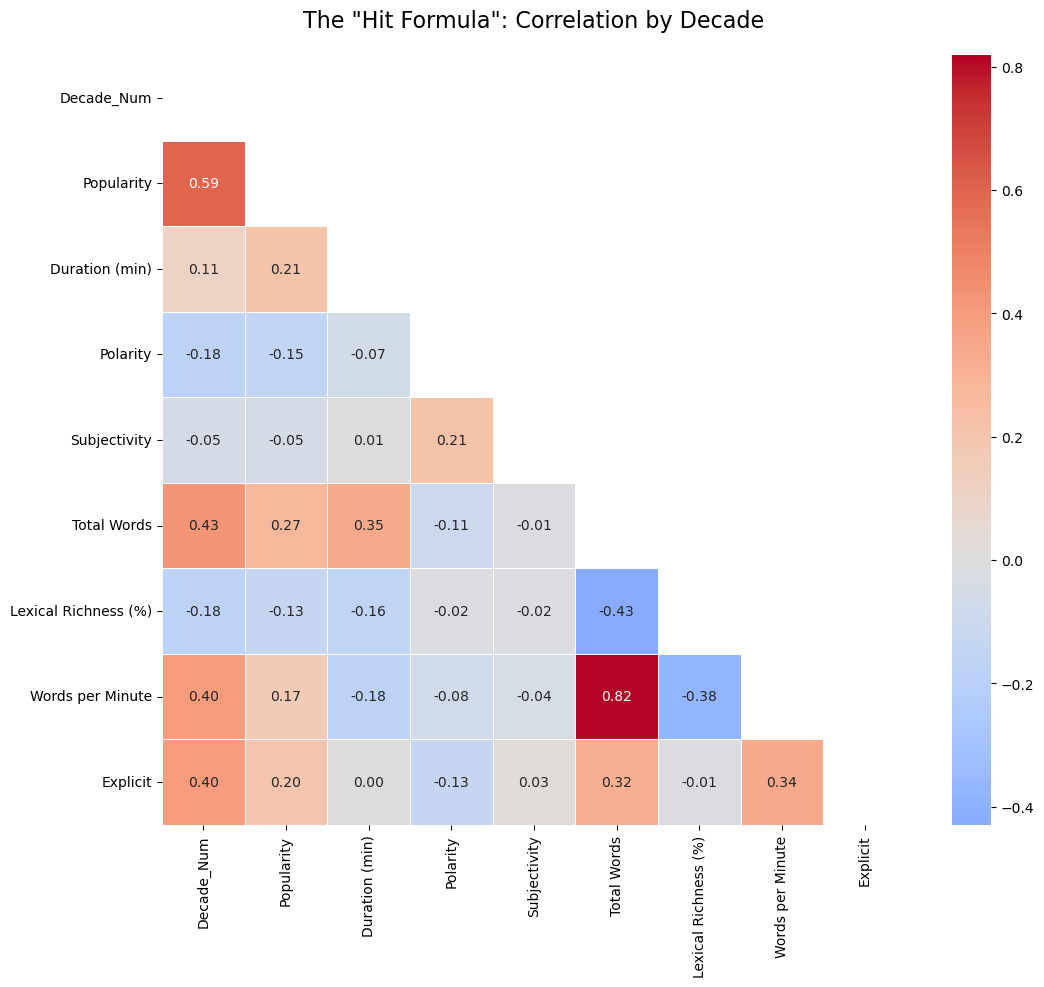

In [86]:
df['Decade_Num'] = df['Decade'].astype(str).str.extract(r'(\d+)').astype(float)

corr_cols = [
    'Decade_Num', 'Popularity', 'Duration (min)', 
    'Polarity', 'Subjectivity', 'Total Words', 
    'Lexical Richness (%)', 'Words per Minute', 'Explicit'
]

df_corr = df[corr_cols].copy()
df_corr['Explicit'] = df['Explicit'].astype(int)

corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    center=0, 
    linewidths=0.5
)

plt.title('The "Hit Formula": Correlation by Decade', fontsize=16, pad=20)
plt.show()

Lets give prizes. Which are the songs that top their categories?

In [ ]:
categories = [
    ("🏎️ Fastest Flow", "Words per Minute", "max", " wpm"),
    ("🐢 Slowest Flow", "Words per Minute", "min", " wpm"),
    ("⏳ Longest Epic", "Duration (min)", "max", " min"),
    ("⚡ Shortest Hit", "Duration (min)", "min", " min"),
    ("🧠 Most Complex", "Lexical Richness (%)", "max", "%"),
    ("🤖 Most Repetitive", "Lexical Richness (%)", "min", "%"),
    ("😊 Happiest Song", "Polarity", "max", ""),
    ("😭 Saddest Song", "Polarity", "min", ""),
    ("📝 Most Subjective", "Subjectivity", "max", ""),
    ("😐 Most Objective", "Subjectivity", "min", "")
]

hall_of_fame_data = []

for title, col, method, unit in categories:
    if method == 'max':
        idx = df[col].idxmax()
    else:
        idx = df[col].idxmin()
        
    row = df.loc[idx]
    
    hall_of_fame_data.append({
        "Award": title,
        "Song": row['Song'],
        "Artist": row['Artist'],
        "Score": f"{row[col]:.2f}{unit}",
        "Decade": row['Decade']
    })

hall_of_fame = pd.DataFrame(hall_of_fame_data)

styled_table = hall_of_fame.style.set_properties(**{'text-align': 'left', 'font-size': '11pt'})\
    .set_table_styles([dict(selector='th', props=[('text-align', 'left'), ('font-size', '12pt')])])\
    .hide(axis='index')

display(styled_table)

most_explicit_decade = df.groupby('Decade')['Explicit'].mean().idxmax()
percentage = df.groupby('Decade')['Explicit'].mean().max() * 100
print(f"\n🔥 Special Mention: The Most Explicit Era was the {most_explicit_decade} ({percentage:.1f}% explicit)")

Award,Song,Artist,Score,Decade
🏎️ Fastest Flow,Stayin' Alive,Bee Gees,286.86 wpm,1970s
🐢 Slowest Flow,Free Bird,Lynyrd Skynyrd,19.75 wpm,1970s
⏳ Longest Epic,Sinnerman,Nina Simone,10.37 min,1960s
⚡ Shortest Hit,Stayin' Alive,Bee Gees,1.55 min,1970s
🧠 Most Complex,Hotel California - 2013 Remaster,Eagles,70.76%,1970s
🤖 Most Repetitive,Around the World,Daft Punk,1.25%,1990s
😊 Happiest Song,Danza Kuduro,Don Omar,0.98,2010s
😭 Saddest Song,Without You (feat. Usher),David Guetta,-1.00,2010s
📝 Most Subjective,We Belong Together,Ritchie Valens,1.00,1950s
😐 Most Objective,Hound Dog,Elvis Presley,0.00,1950s



🔥 Special Mention: The Most Explicit Era was the 2020s (41.0% explicit)
